In [85]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from config import BCI2A_PATH, MI_DATA_PATH, LOW_FREQ, HIGH_FREQ, SAMPLING_RATE, BCI_MAPPING

In [86]:
def load_data(path, channels = ['C3', 'C4', 'Cz'], format = '.gdf', sampling_rate = SAMPLING_RATE, low_freq = LOW_FREQ, high_freq = HIGH_FREQ, mapping = None, transform = None):
    parent_dir = os.path.dirname(path)
    raw_files = [os.path.join(parent_dir, f) for f in os.listdir(parent_dir) if f.endswith(format)]
    print(f"Found {len(raw_files)} raw data files in {path}.")
    raw_data = []
    for file in raw_files:
        raw = mne.io.read_raw_gdf(file, preload=True)

        if raw.info['sfreq'] != sampling_rate:
            raw.resample(sampling_rate)

        if transform is not None:
            raw.rename_channels(lambda x: transform(x))        

        if mapping is not None:
            raw.rename_channels(mapping)

        if channels is not None:
            raw.pick_channels(channels)
        else:
            raw.pick_types(eeg=True)
        
        # raw.set_montage('standard_1020')

        raw.filter(low_freq, high_freq)

        raw_data.append(raw)
    return raw_data    
    print(f"Loaded and preprocessed {len(raw_data)} raw data files from {path}.")

In [87]:
def bci2a_transform(channel_name):
    return channel_name.replace('EEG-', '')

In [88]:
drop_channels = ['EOG-left', 'EOG-central', 'EOG-right']

training_bci = load_data(
    path = BCI2A_PATH,
    transform = bci2a_transform,
    mapping = BCI_MAPPING,
    channels=None,
    low_freq=4, 
    high_freq=40, 
    format = 'T.gdf')


evaluation_bci = load_data(
    path = BCI2A_PATH,
    transform = bci2a_transform,
    mapping = BCI_MAPPING,
    channels=None,
    low_freq=4,
    high_freq=40,
    format = 'E.gdf')

Found 9 raw data files in ./data/BCI-2A/.
Extracting GDF parameters from ./data/BCI-2A\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Extracting GDF parameters from ./data/BCI-2A\A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure.

C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Extracting GDF parameters from ./data/BCI-2A\A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure.

...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Extracting GDF parameters from ./data/BCI-2A\A08E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure.

C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Extracting GDF parameters from ./data/BCI-2A\A09E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure.

C:\Users\Madhav\AppData\Roaming\uv\python\cpython-3.13.7-windows-x86_64-none\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)



In [89]:
print(f"Loaded Training BCI2A data: {len(training_bci)} files")
print(f"Loaded Evaluation BCI2A data: {len(evaluation_bci)} files")

Loaded Training BCI2A data: 9 files
Loaded Evaluation BCI2A data: 9 files


# Extracting Events from Training Files 

In [90]:

event, event_id = mne.events_from_annotations(training_bci[0])
print(f"Events found: {event_id}")
print(f"Event : {event.shape}" )


Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Events found: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Event : (603, 3)


In [91]:
BCI_Label_Mappings = {
    np.str_("769"): 0,  # Left Hand
    np.str_("770"): 1,  # Right Hand
    np.str_("771"): 2,  # Foot
    np.str_("772"): 3,  # Tongue
}

In [92]:
from mne.preprocessing import ICA

def run_ica(raw, n_components=20):
    ica = ICA(n_components=n_components, random_state=42, max_iter="auto")
    ica.fit(raw)

    raw_clean = raw.copy()
    ica.apply(raw_clean)

    return raw_clean

def create_epochs(raw, event_id, tmin=-2.0, tmax=2.0, baseline=None):
    events, _ = mne.events_from_annotations(raw, event_id=event_id)
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True
    )
    return epochs


def normalize_epochs(epochs):
    X = epochs.get_data() 
    mean = X.mean(axis=(0, 2), keepdims=True)
    std = X.std(axis=(0, 2), keepdims=True)
    X = (X - mean) / std
    y = epochs.events[:, -1]
    return X, y

def prepare_for_transformer(X):
    # (n_trials, n_channels, n_times) -> (n_trials, n_times, n_channels)
    return np.transpose(X, (0, 2, 1))


def preprocess_raw(raw, event_id, n_ica_components=20, tmin=-2.0, tmax=2.0, baseline=None):
    raw_clean = run_ica(raw, n_components=n_ica_components)
    epochs = create_epochs(raw_clean, event_id, tmin, tmax, baseline)
    X, y = normalize_epochs(epochs)
    X = prepare_for_transformer(X)
    return X, y


X_list, y_list = [], []
for raw in training_bci:
    X_raw, y_raw = preprocess_raw(raw, event_id=BCI_Label_Mappings)
    X_list.append(X_raw)
    y_list.append(y_raw)

X_train = np.concatenate(X_list)
y_train = np.concatenate(y_list)

print(f"Final data shape: {X_train.shape}, labels: {y_train.shape}")

Fitting ICA to data using 25 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 21.1s.
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 0 ICA components
    Projecting back using 25 PCA components
Used Annotations descriptions: [np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Fitting ICA to data using 25 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 11.0s.
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 0 ICA components
    Projecting back using 25 PCA components
Used Annotations descriptions: [np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metad

In [106]:
X_test, y_test = [], []
for raw in evaluation_bci:
    X_raw, y_raw = preprocess_raw(raw, event_id=BCI_Label_Mappings)
    X_test.append(X_raw)
    y_test.append(y_raw)

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

print(f"Final data shape: {X_test.shape}, labels: {y_test.shape}")

Fitting ICA to data using 25 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 11.4s.
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 0 ICA components
    Projecting back using 25 PCA components


ValueError: Could not find any of the events you specified.

In [93]:
X_train.shape, y_train.shape

((2592, 1001, 25), (2592,))

In [94]:
# Checking Balance in Training Data
unique, counts = np.unique(y_train, return_counts=True)
print("Class Distribution in Training Data:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} samples")


Class Distribution in Training Data:
Class 0: 648 samples
Class 1: 648 samples
Class 2: 648 samples
Class 3: 648 samples


# TRAIN TEST SPLIT 

In [95]:
import torch
import torch.nn as nn

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}") 

Training set: (2203, 1001, 25), (2203,)
Validation set: (389, 1001, 25), (389,)


In [97]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

In [98]:
from torch.utils.data import DataLoader, TensorDataset
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# SAMPLE CLASSIFICATION MODEL 

In [99]:
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        # CNN
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Dropout(0.3)
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.Dropout(0.3)
        )

        # LSTM
        self.lstm1 = nn.LSTM(128, 200, batch_first=True)
        self.lstm2 = nn.LSTM(200, 100, batch_first=True)

        # FC
        self.fc = nn.Linear(100, n_classes)

    def forward(self, x):
        # x: (B, T, C) → (B, C, T)
        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.conv2(x)

        # back to (B, T, C)
        x = x.permute(0, 2, 1)

        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)

        x = x[:, -1, :]  # last timestep

        return self.fc(x)

In [100]:
model = CNN_LSTM(n_channels=X_train.shape[2], n_classes=4)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [101]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    preds, labels = [], []
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels, preds)

    return avg_loss, acc

In [102]:
from tqdm import tqdm
import torch

def train(model, train_loader, val_loader, optimizer, criterion, epochs=20, device="cpu"):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

        for X_batch, y_batch in loop:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [103]:
def final_evaluation(model, loader, device="cpu"):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.numpy())

    print("Final Accuracy:", accuracy_score(labels, preds))
    print(classification_report(labels, preds))

In [104]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(history["val_acc"], label="Val Accuracy")
    plt.legend()
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

In [ ]:
history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=500,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

plot_history(history)
final_evaluation(model, val_loader)

# ATTENTION BASED 

In [ ]:
import torch
import torch.nn as nn

class CNNTransformer(nn.Module):
    def __init__(self, n_channels=25, n_classes=4):
        super().__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2)
        )

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Classification
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (N, T, C)
        x = x.permute(0, 2, 1)  # (N, C, T)

        x = self.cnn(x)  # (N, 128, T')

        x = x.permute(0, 2, 1)  # (N, T', 128)

        x = self.transformer(x)  # (N, T', 128)

        x = x.mean(dim=1)  # Global average pooling

        x = self.fc(x)

        return x

In [ ]:
from tqdm import trange
device = 'cuda' if torch.cuda.is_available() else 'cpu'


lr = 1e-4
batch_size = 32
epochs = 40

In [ ]:


model = CNNTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
criterion = nn.CrossEntropyLoss()

X_train_tensor, y_train_tensor = X_train_tensor.    to(device), y_train_tensor.to(device)
X_val_tensor, y_val_tensor = X_val_tensor.to(device), y_val_tensor.to(device)

C:\Users\Madhav\AppData\Local\Temp\ipykernel_19352\2717855529.py:8: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [80]:
from torch.utils.data import DataLoader, TensorDataset
BATCH_SIZE = 32 

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [82]:
train_loss_history = []
val_acc_history = []

for epoch in trange(20, desc="Training Epochs"):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    
    train_loss_history.append(train_loss / len(train_loader.dataset))

    # validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
        val_acc = correct / total

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

Training Epochs:   5%|▌         | 1/20 [00:10<03:20, 10.55s/it]

Epoch 1: Train Loss=3137.4466, Val Acc=0.2494


Training Epochs:  10%|█         | 2/20 [00:20<03:01, 10.09s/it]

Epoch 2: Train Loss=3072.6013, Val Acc=0.2725


Training Epochs:  15%|█▌        | 3/20 [00:30<02:49,  9.94s/it]

...

Epoch 18: Train Loss=2988.2463, Val Acc=0.3650


Training Epochs:  95%|█████████▌| 19/20 [06:08<00:28, 28.28s/it]

Epoch 19: Train Loss=2982.0783, Val Acc=0.3393


Training Epochs: 100%|██████████| 20/20 [06:37<00:00, 19.90s/it]

Epoch 20: Train Loss=2985.5283, Val Acc=0.3599


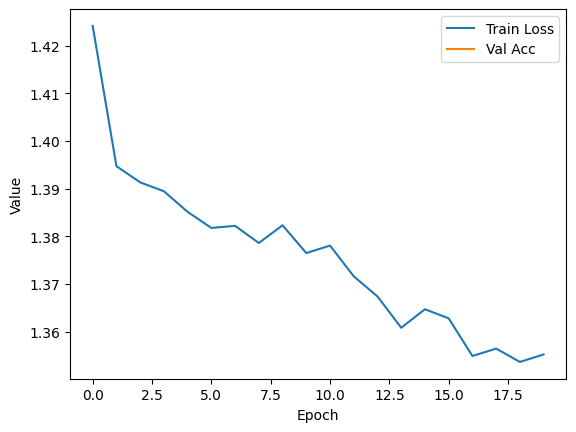

In [83]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_acc_history, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()